In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import Bidirectional, LSTM
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [ ]:
!pip install datasets

In [4]:
from datasets import load_dataset

dataset = load_dataset("dair-ai/emotion")

README.md:   0%|          | 0.00/9.05k [00:00<?, ?B/s]

split/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.03MB            

split/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  127kB            

split/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  129kB            

split/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [5]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [6]:
import pandas as pd

train_df = dataset["train"].to_pandas()
validation_df = dataset["validation"].to_pandas()
test_df = dataset["test"].to_pandas()

In [7]:
train_df.head()

,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


In [8]:
print("Training samples:", len(train_df))
print("Validation samples:", len(validation_df))
print("Testing samples:", len(test_df))

Training samples: 16000
Validation samples: 2000
Testing samples: 2000


In [9]:
train_df["label"].value_counts().sort_index()

,count
label,
0,4666
1,5362
2,1304
3,2159
4,1937
5,572


In [10]:
train_df.head(10)

,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3
5,ive been feeling a little burdened lately wasn...,0
6,ive been taking or milligrams or times recomme...,5
7,i feel as confused about life as a teenager or...,4
8,i have been with petronas for years i feel tha...,1
9,i feel romantic too,2


In [11]:
print(train_df.columns)

Index(['text', 'label'], dtype='object')


In [12]:
label_names = dataset["train"].features["label"].names

print(label_names)

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']


In [13]:
print("Training missing values:")
print(train_df.isnull().sum())

print("\nValidation missing values:")
print(validation_df.isnull().sum())

print("\nTesting missing values:")
print(test_df.isnull().sum())

Training missing values:
text     0
label    0
dtype: int64

Validation missing values:
text     0
label    0
dtype: int64

Testing missing values:
text     0
label    0
dtype: int64


In [14]:
print("Duplicate rows in training data:", train_df.duplicated().sum())
print("Duplicate rows in validation data:", validation_df.duplicated().sum())
print("Duplicate rows in testing data:", test_df.duplicated().sum())

Duplicate rows in training data: 1
Duplicate rows in validation data: 0
Duplicate rows in testing data: 0


In [15]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [16]:
sample_text = "I AM SO HAPPY!!! 😊"

print("Before:", sample_text)
print("After:", clean_text(sample_text))

Before: I AM SO HAPPY!!! 😊
After: i am so happy


In [17]:
train_df["clean_text"] = train_df["text"].apply(clean_text)
validation_df["clean_text"] = validation_df["text"].apply(clean_text)
test_df["clean_text"] = test_df["text"].apply(clean_text)

In [18]:
train_df[["text", "clean_text", "label"]].head(10)

,text,clean_text,label
0,i didnt feel humiliated,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,i am feeling grouchy,3
5,ive been feeling a little burdened lately wasn...,ive been feeling a little burdened lately wasn...,0
6,ive been taking or milligrams or times recomme...,ive been taking or milligrams or times recomme...,5
7,i feel as confused about life as a teenager or...,i feel as confused about life as a teenager or...,4
8,i have been with petronas for years i feel tha...,i have been with petronas for years i feel tha...,1
9,i feel romantic too,i feel romantic too,2


In [19]:
train_df["text_length"] = train_df["clean_text"].apply(lambda x: len(x.split()))

print("Average sentence length:",
      train_df["text_length"].mean())

print("Maximum sentence length:",
      train_df["text_length"].max())

print("Minimum sentence length:",
      train_df["text_length"].min())

Average sentence length: 19.1663125
Maximum sentence length: 66
Minimum sentence length: 2


In [20]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [21]:
tokenizer = Tokenizer(
    num_words=10000,
    oov_token="<OOV>"
)

In [22]:
tokenizer.fit_on_texts(train_df["clean_text"])

In [23]:
word_index = tokenizer.word_index

print("Total unique words:", len(word_index))

Total unique words: 15213


In [24]:
list(word_index.items())[:20]

[('<OOV>', 1),
 ('i', 2),
 ('feel', 3),
 ('and', 4),
 ('to', 5),
 ('the', 6),
 ('a', 7),
 ('feeling', 8),
 ('that', 9),
 ('of', 10),
 ('my', 11),
 ('in', 12),
 ('it', 13),
 ('like', 14),
 ('so', 15),
 ('for', 16),
 ('im', 17),
 ('me', 18),
 ('but', 19),
 ('was', 20)]

In [25]:
X_train_sequences = tokenizer.texts_to_sequences(train_df["clean_text"])
X_validation_sequences = tokenizer.texts_to_sequences(validation_df["clean_text"])
X_test_sequences = tokenizer.texts_to_sequences(test_df["clean_text"])

In [26]:
print("Original text:")
print(train_df["clean_text"].iloc[0])

print("\nTokenized sequence:")
print(X_train_sequences[0])

Original text:
i didnt feel humiliated

Tokenized sequence:
[2, 139, 3, 679]


In [27]:
MAX_LENGTH = 50

In [28]:
X_train = pad_sequences(
    X_train_sequences,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

X_validation = pad_sequences(
    X_validation_sequences,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

X_test = pad_sequences(
    X_test_sequences,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

In [29]:
print("Training shape:", X_train.shape)
print("Validation shape:", X_validation.shape)
print("Testing shape:", X_test.shape)

Training shape: (16000, 50)
Validation shape: (2000, 50)
Testing shape: (2000, 50)


In [30]:
y_train = train_df["label"].values
y_validation = validation_df["label"].values
y_test = test_df["label"].values

In [31]:
print("Training labels shape:", y_train.shape)
print("Validation labels shape:", y_validation.shape)
print("Testing labels shape:", y_test.shape)

Training labels shape: (16000,)
Validation labels shape: (2000,)
Testing labels shape: (2000,)


In [32]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: []


In [34]:
VOCAB_SIZE = min(10000, len(tokenizer.word_index) + 1)
EMBEDDING_DIM = 128
LSTM_UNITS = 64
NUM_CLASSES = 6

print("Vocabulary size:", VOCAB_SIZE)
print("Embedding dimension:", EMBEDDING_DIM)
print("LSTM units:", LSTM_UNITS)
print("Number of classes:", NUM_CLASSES)

Vocabulary size: 10000
Embedding dimension: 128
LSTM units: 64
Number of classes: 6


In [35]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import Bidirectional, LSTM
from tensorflow.keras.layers import Dense, Dropout

In [36]:
model = Sequential([
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        input_length=MAX_LENGTH
    ),

    Bidirectional(
        LSTM(LSTM_UNITS)
    ),

    Dropout(0.5),

    Dense(64, activation="relu"),

    Dropout(0.3),

    Dense(NUM_CLASSES, activation="softmax")
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [37]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [38]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [39]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=1,
    min_lr=1e-6
)

In [40]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_validation, y_validation),
    epochs=10,
    batch_size=64,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 23s 81ms/step - accuracy: 0.4428 - loss: 1.4010 - val_accuracy: 0.7010 - val_loss: 0.8339 - learning_rate: 0.0010
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 21s 83ms/step - accuracy: 0.7797 - loss: 0.6061 - val_accuracy: 0.8630 - val_loss: 0.4389 - learning_rate: 0.0010
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 39s 75ms/step - accuracy: 0.9127 - loss: 0.2757 - val_accuracy: 0.8890 - val_loss: 0.3559 - learning_rate: 0.0010
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 21s 84ms/step - accuracy: 0.9511 - loss: 0.1604 - val_accuracy: 0.8945 - val_loss: 0.3354 - learning_rate: 0.0010
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 40s 81ms/step - accuracy: 0.9674 - loss: 0.1126 - val_accuracy: 0.8995 - val_loss: 0.4106 - learning_rate: 0.0010
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 19s 76ms/step - accuracy: 0.9787 - loss: 0.0687 - val_accuracy: 0.9010 - val_loss: 0.3916 - learning_rate: 5.0000e-04


In [41]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss', 'learning_rate'])


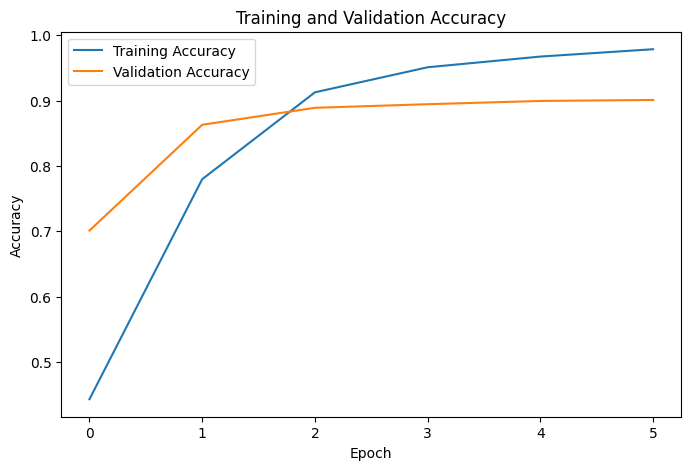

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

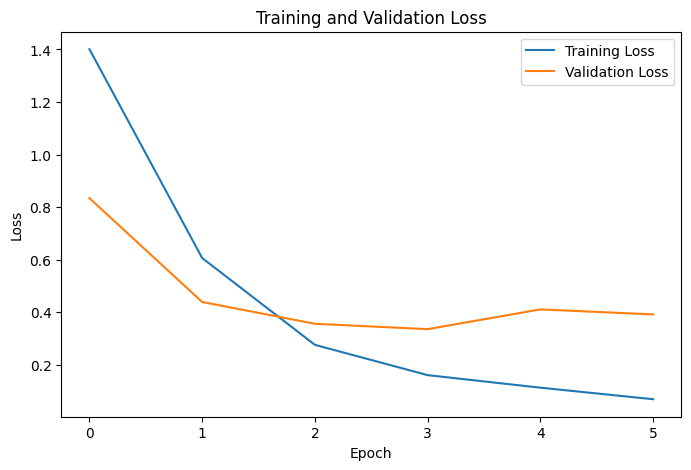

In [43]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [44]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8795 - loss: 0.3615
Test Loss: 0.361514687538147
Test Accuracy: 0.8794999718666077


In [45]:
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

print("Predicted labels:")
print(y_pred[:20])

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step
Predicted labels:
[0 0 0 1 0 4 3 0 1 3 4 0 0 1 2 0 1 0 3 1]


In [46]:
np.argmax(...)

np.int64(0)

In [47]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_names
    )
)

              precision    recall  f1-score   support

     sadness       0.93      0.93      0.93       581
         joy       0.92      0.89      0.91       695
        love       0.70      0.84      0.76       159
       anger       0.94      0.81      0.87       275
        fear       0.89      0.83      0.86       224
    surprise       0.51      0.86      0.64        66

    accuracy                           0.88      2000
   macro avg       0.82      0.86      0.83      2000
weighted avg       0.89      0.88      0.88      2000



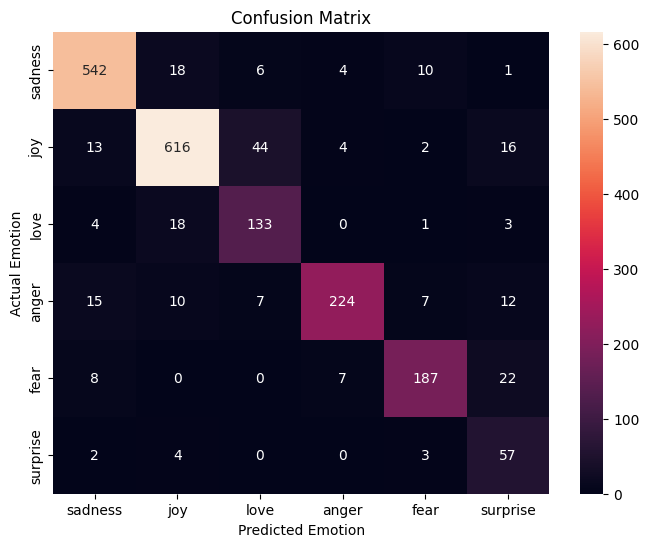

In [48]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=label_names,
    yticklabels=label_names
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Emotion")
plt.ylabel("Actual Emotion")

plt.show()

In [49]:
model.save("emotion_detection_bilstm.keras")

print("Model saved successfully!")

Model saved successfully!


In [50]:
import pickle

with open("tokenizer.pkl", "wb") as file:
    pickle.dump(tokenizer, file)

print("Tokenizer saved successfully!")

Tokenizer saved successfully!


In [51]:
emotion_labels = {
    0: "Sadness",
    1: "Joy",
    2: "Love",
    3: "Anger",
    4: "Fear",
    5: "Surprise"
}

print(emotion_labels)

{0: 'Sadness', 1: 'Joy', 2: 'Love', 3: 'Anger', 4: 'Fear', 5: 'Surprise'}


In [52]:
def predict_emotion(text):
    # Clean the input text
    cleaned_text = clean_text(text)

    # Convert text into a sequence of numbers
    sequence = tokenizer.texts_to_sequences([cleaned_text])

    # Apply padding
    padded_sequence = pad_sequences(
        sequence,
        maxlen=MAX_LENGTH,
        padding="post",
        truncating="post"
    )

    # Get prediction probabilities
    probabilities = model.predict(padded_sequence, verbose=0)[0]

    # Find the emotion with highest probability
    predicted_label = np.argmax(probabilities)

    # Get emotion name
    predicted_emotion = emotion_labels[predicted_label]

    # Get confidence
    confidence = probabilities[predicted_label] * 100

    return predicted_emotion, confidence

In [53]:
text = "I am extremely happy today!"

emotion, confidence = predict_emotion(text)

print("Input:", text)
print("Predicted Emotion:", emotion)
print("Confidence:", round(confidence, 2), "%")

Input: I am extremely happy today!
Predicted Emotion: Joy
Confidence: 30.06 %


In [54]:
test_sentences = [
    "I am so happy that I got selected!",
    "I feel very lonely and sad.",
    "I am extremely angry with him.",
    "I am scared about what will happen.",
    "I really love my family.",
    "Wow! I never expected this!"
]

for sentence in test_sentences:
    emotion, confidence = predict_emotion(sentence)

    print("Text:", sentence)
    print("Emotion:", emotion)
    print("Confidence:", round(confidence, 2), "%")
    print("-" * 60)

Text: I am so happy that I got selected!
Emotion: Joy
Confidence: 87.45 %
------------------------------------------------------------
Text: I feel very lonely and sad.
Emotion: Sadness
Confidence: 99.87 %
------------------------------------------------------------
Text: I am extremely angry with him.
Emotion: Anger
Confidence: 75.48 %
------------------------------------------------------------
Text: I am scared about what will happen.
Emotion: Fear
Confidence: 95.37 %
------------------------------------------------------------
Text: I really love my family.
Emotion: Surprise
Confidence: 30.61 %
------------------------------------------------------------
Text: Wow! I never expected this!
Emotion: Surprise
Confidence: 43.81 %
------------------------------------------------------------


In [55]:
test_sentences = [
    "I am extremely happy because I got selected for my dream job.",
    "I feel very sad and lonely today.",
    "I am so angry with my friend for lying to me.",
    "I am scared about the result of my examination.",
    "I really love spending time with my family.",
    "Wow! I cannot believe that I won the competition.",
    "I am feeling great and excited about my future.",
    "I feel completely hopeless and disappointed.",
    "This situation makes me extremely angry.",
    "I am worried that something bad might happen.",
    "I love my parents and I am grateful for everything they do.",
    "What a wonderful and unexpected surprise!",
    "I am feeling cheerful after receiving good news.",
    "I am afraid of going to the interview tomorrow.",
    "I feel terrible because I failed my test."
]

for sentence in test_sentences:
    emotion, confidence = predict_emotion(sentence)

    print("Text:", sentence)
    print("Predicted Emotion:", emotion)
    print("Confidence:", round(confidence, 2), "%")
    print("-" * 70)

Text: I am extremely happy because I got selected for my dream job.
Predicted Emotion: Joy
Confidence: 65.17 %
----------------------------------------------------------------------
Text: I feel very sad and lonely today.
Predicted Emotion: Sadness
Confidence: 99.94 %
----------------------------------------------------------------------
Text: I am so angry with my friend for lying to me.
Predicted Emotion: Anger
Confidence: 94.62 %
----------------------------------------------------------------------
Text: I am scared about the result of my examination.
Predicted Emotion: Fear
Confidence: 97.2 %
----------------------------------------------------------------------
Text: I really love spending time with my family.
Predicted Emotion: Surprise
Confidence: 38.74 %
----------------------------------------------------------------------
Text: Wow! I cannot believe that I won the competition.
Predicted Emotion: Surprise
Confidence: 54.33 %
---------------------------------------------------

In [56]:
def show_emotion_probabilities(text):
    cleaned_text = clean_text(text)

    sequence = tokenizer.texts_to_sequences([cleaned_text])

    padded_sequence = pad_sequences(
        sequence,
        maxlen=MAX_LENGTH,
        padding="post",
        truncating="post"
    )

    probabilities = model.predict(
        padded_sequence,
        verbose=0
    )[0]

    print("Input:", text)
    print("\nEmotion probabilities:")

    for i, probability in enumerate(probabilities):
        print(
            f"{emotion_labels[i]:10s}: {probability * 100:.2f}%"
        )

In [57]:
show_emotion_probabilities(
    "I am extremely happy about my examination result!"
)

Input: I am extremely happy about my examination result!

Emotion probabilities:
Sadness   : 17.57%
Joy       : 20.01%
Love      : 2.28%
Anger     : 10.12%
Fear      : 34.67%
Surprise  : 15.35%


In [58]:
def get_prediction(text):
    cleaned_text = clean_text(text)

    sequence = tokenizer.texts_to_sequences([cleaned_text])

    padded_sequence = pad_sequences(
        sequence,
        maxlen=MAX_LENGTH,
        padding="post",
        truncating="post"
    )

    probabilities = model.predict(
        padded_sequence,
        verbose=0
    )[0]

    predicted_label = np.argmax(probabilities)

    predicted_emotion = emotion_labels[predicted_label]

    confidence = probabilities[predicted_label] * 100

    return predicted_emotion, confidence, probabilities

In [59]:
emotion, confidence, probabilities = get_prediction(
    "I am very excited about my new project!"
)

print("Predicted Emotion:", emotion)
print("Confidence:", round(confidence, 2), "%")

Predicted Emotion: Joy
Confidence: 90.25 %


In [60]:
import pickle

with open("emotion_labels.pkl", "wb") as file:
    pickle.dump(emotion_labels, file)

print("Emotion labels saved successfully!")

Emotion labels saved successfully!
